Model Evaluation Results:


,MAE,RMSE,R2
LinearRegression,4.877354e-13,5.924330e-13,1.000000
RandomForest,3.904235e+00,1.435767e+01,0.974834
XGBoost,4.073482e+00,1.252261e+01,0.980856


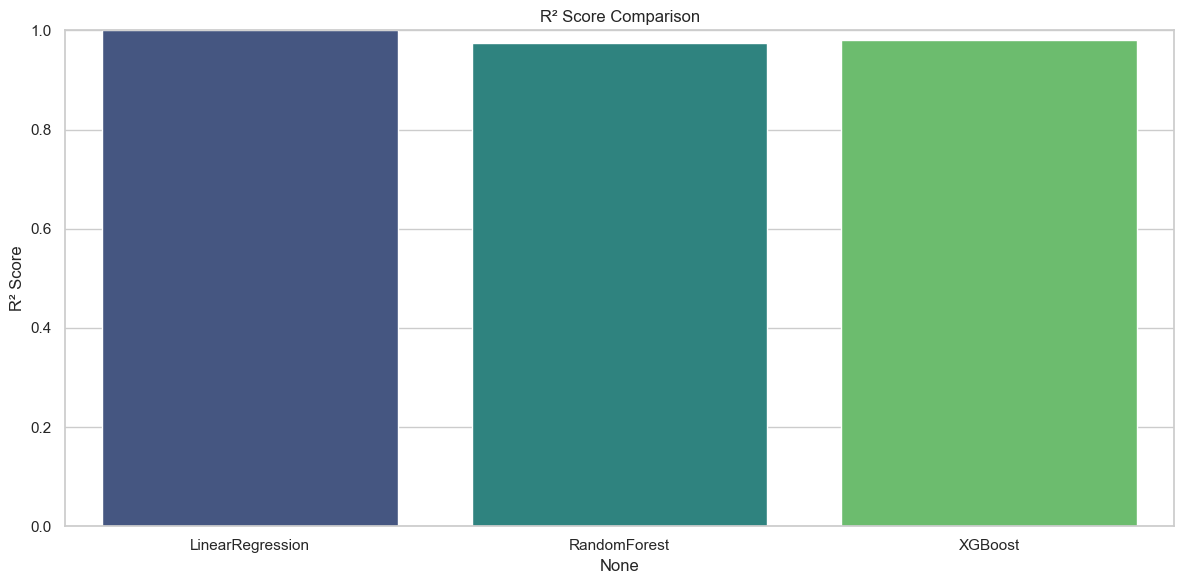

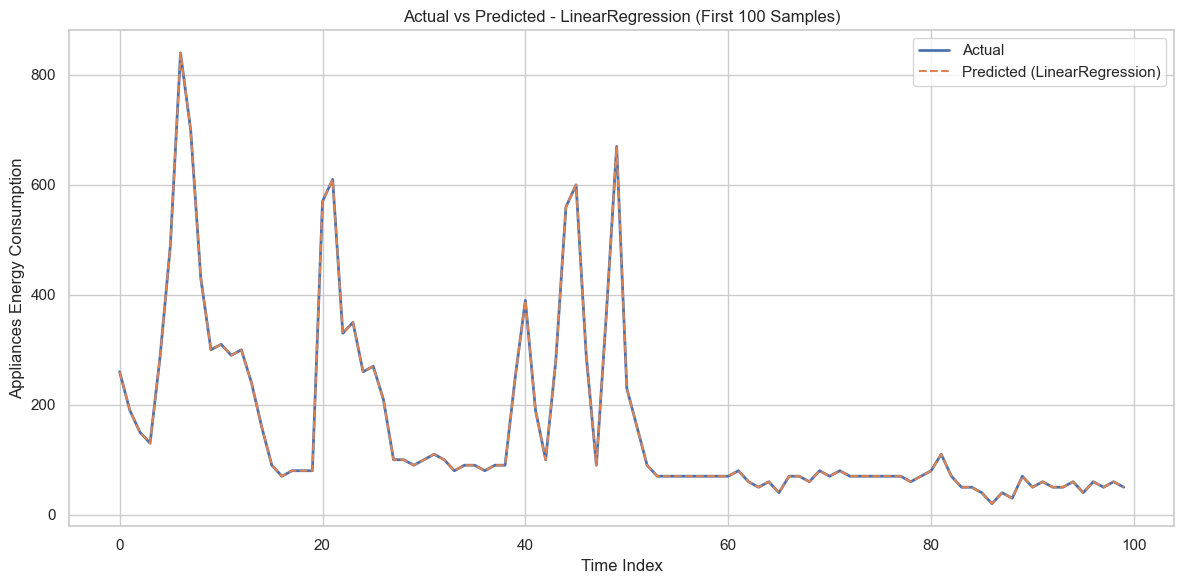

In [1]:
# Importting libraries.
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings("ignore")

# Plot style
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# Loading feature-engineered data.
df = pd.read_csv("../data/processed/energydata_features.csv", parse_dates=["date"], index_col="date")

# Defining target and features.
target = "Appliances"
features = df.drop(columns=[target]).columns.tolist()

X = df[features]
y = df[target]

# Train-test split
split_index = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

# Loading the models.
model_paths = {
    "LinearRegression": "../models/LinearRegression_model.pkl",
    "RandomForest": "../models/RandomForest_model.pkl",
    "XGBoost": "../models/XGBoost_model.pkl"
}

models = {}
for name, path in model_paths.items():
    with open(path, "rb") as f:
        models[name] = pickle.load(f)

# Evaluating the models.
results = {}
predictions = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    predictions[name] = y_pred

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results[name] = {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

# Converting to required DataFrame.
results_df = pd.DataFrame(results).T
print("Model Evaluation Results:")
display(results_df)

# Saving evaluation results.
results_df.to_csv("../outputs/reports/model_evaluation_summary.csv")

# Plotting R2 scores.
plt.figure()
sns.barplot(x=results_df.index, y=results_df["R2"], palette="viridis")
plt.title("R² Score Comparison")
plt.ylabel("R² Score")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

# Visualizing predictions vs actual for the best model.
best_model_name = results_df["R2"].idxmax()
best_model = models[best_model_name]
best_pred = best_model.predict(X_test)

plt.figure()
plt.plot(y_test.values[:100], label="Actual", linewidth=2)
plt.plot(best_pred[:100], label=f"Predicted ({best_model_name})", linestyle="--")
plt.title(f"Actual vs Predicted - {best_model_name} (First 100 Samples)")
plt.xlabel("Time Index")
plt.ylabel("Appliances Energy Consumption")
plt.legend()
plt.tight_layout()
plt.show()
